In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Load both datasets
url_1 = 'https://raw.githubusercontent.com/pablo9ja/NRF_work/main/Prostate%20Cancer%202.xlsx'
url_2 = 'https://raw.githubusercontent.com/pablo9ja/NRF_work/main/Prostate%20Data%2022.xlsx'

df = pd.read_excel(url_1)   # shape: (42, 29)
df2 = pd.read_excel(url_2)  # shape: (1013, 30)
df4 = pd.read_excel('C:\Users\lenovo\Documents\GitHub\NRF\NRF_work\merged_prostrate_cancer_data.xlsx')
# Align df2 to have the same columns as df (in same order)
df2_aligned = df2[df.columns.intersection(df2.columns)]  # retain common columns
df2_aligned = df2_aligned.reindex(columns=df.columns)    # match the exact order of df's columns

# Concatenate the two DataFrames
df3 = pd.concat([df, df2_aligned], ignore_index=True)
print(df.shape)
print(df2.shape)
print(df3.shape)


(42, 29)
(1013, 30)
(1055, 29)


In [64]:
df.columns

Index(['S/N', 'NAMES', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'PSA (ng/ml)', 'DRE', 'BIOPSY CORES',
       'FINDINGS'],
      dtype='object')

In [65]:
df2.columns

Index(['NAMES', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'PSA (ng/ml)', 'DRE', 'BIOPSY CORES',
       'FINDINGS', 'Unnamed: 28', 'Unnamed: 29'],
      dtype='object')

In [66]:
df3.columns

Index(['S/N', 'NAMES', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'PSA (ng/ml)', 'DRE', 'BIOPSY CORES',
       'FINDINGS'],
      dtype='object')

In [67]:
for x in df3.columns:
    if df3[x].isna().sum() >200:
        print(f"{x}: {df3[x].isna().sum()} missing values")


S/N: 1013 missing values
MEDICAL CONDITIONS: 973 missing values
ENGAGEMENT IN PHYSICAL EXERCISE: 335 missing values
PSA (ng/ml): 426 missing values
DRE: 843 missing values


In [68]:
extra_columns = df2.columns.difference(df.columns)
print("Extra columns:", extra_columns)
missing_percentage = df2[extra_columns].isna().mean() * 100  # Calculate percentage of missing values

columns_missing_50_plus = missing_percentage[missing_percentage > 50]
print("Columns with more than 50% missing values:", columns_missing_50_plus)


Extra columns: Index(['Unnamed: 28', 'Unnamed: 29'], dtype='object')
Columns with more than 50% missing values: Unnamed: 28    92.201382
Unnamed: 29    99.901283
dtype: float64


In [69]:
#df3 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
#df3.head(2)

In [70]:
# Clean column names
df3.columns = (
    df3.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
)
df3.head(2)

,sn,names,age,gender,hospital_no,lab_no,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,medical_conditions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,psa_ngml,dre,biopsy_cores,findings
0,1.0,ALIYU USMAN,73.0,MALE,NaN,NaN,SOKOTO,MARRIED,TERTIARY,SKILLED,LESS THAN 70000 NAIRA,HAUSA,FAMILY HISTORY; MOTHER'S SISTER WITH BREAST CA...,"DRIBBLING OF URINE, INCOMPLETE VOIDING, LACK O...","HYPERTENSION, DEPRESSION",153,53,Moderate,High in carbohydrate and processed foods,2,NO,NO,Moderate,No,7 to 8 hours,12.23,"ENLARGED, MEDIAN GROVE",4.0,Prostrate (biopsy)- Nodular hyperplasia
1,2.0,SAIDU ABUBAKAR,58.0,MALE,NaN,900624,SOKOTO,MARRIED,TERTIARY,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,"FREQUENT URINATION, NOCTURIA, LACK OF RECTION",HYPERTENSION,155,51,Little,High in carbohydrate and processed foods,2,NO,NO,Moderate,Yes,More than 8 hours,19.07,NaN,NaN,Prostrate (biopsy)- Nodular hyperplasia


In [71]:
df3['monthly_income'].value_counts()

monthly_income
Less than ₦70,000         734
₦80,000 to ₦150,000       204
More than ₦150,000         75
LESS THAN 70000 NAIRA      29
80000-150000 NAIRA         12
MORE THAN 160000 NAIRA      1
Name: count, dtype: int64

In [72]:
df3['psa_ngml'].isna().sum()

np.int64(426)

In [73]:
def clean_healthcare_data(df):
    # avoid SettingWithCopyWarning
    df = df.copy()

    # Drop columns with more than 30% missing values
    missing_threshold = int(0.7 * len(df))
    df = df.dropna(axis=1, thresh=missing_threshold)

    # Drop specific irrelevant columns if they exist
    columns_to_drop = ['sn','hospital_no', 'names', 'lab_no', 'gender']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

    # Forward fill and backward fill missing values
    df = df.ffill().bfill()

    # Convert all string values in the DataFrame to lowercase
    df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

    df['bmi'] = df['weight'] / (df['height_cm']/100)**2

    # Clean specific columns only if they exist
    if 'engagement_in_physical_exercise' in df.columns:
        df['engagement_in_physical_exercise'] = df['engagement_in_physical_exercise'].str.strip()

    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

    if 'highest_level_of_education' in df.columns:
      df['highest_level_of_education'] = (
        df['highest_level_of_education']
        .replace({
            'non-formal': 'non-formal',
            'non formal education': 'non-formal',
            'secondary level education': 'secondary',
            'primary level education': 'primary'
        }))

    if 'height_cm' in df.columns:
        df['height_cm'] = pd.to_numeric(
            df['height_cm'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('cm', '', regex=True),
            errors='coerce'
        )

    if 'weight' in df.columns:
        df['weight'] = pd.to_numeric(
            df['weight'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('kg', '', regex=True),
            errors='coerce'
        )

    if 'meals_taken_in_a_day' in df.columns:
        meal_mapping = {'above': 5}
        meals = df['meals_taken_in_a_day'].replace(meal_mapping)
        df['meals_taken_in_a_day'] = pd.to_numeric(
            meals.astype(str),
            errors='coerce'
        ).infer_objects(copy=False)

    if 'hours_of_sleep_per_night' in df.columns:
        sleep_mapping = {
            'less than 5 hours': 4,
            '5 to 6 hours': 5.5,
            '7 to 8 hours': 7.5,
            'more than 8 hours': 9
        }
        sleep = df['hours_of_sleep_per_night'].replace(sleep_mapping)
        df['hours_of_sleep_per_night'] = pd.to_numeric(
            sleep.astype(float),
            errors='coerce'
        ).infer_objects(copy=False)

    if 'monthly_income' in df.columns:
        # Standardize the income strings
        df['monthly_income'] = (
            df['monthly_income']
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r'[,\s₦]+', '', regex=True)
            .str.replace('to', '-')
            .str.replace('andabove', '+')
            .str.replace('morethan', '>')
            .str.replace('lessthan', '<')
            .str.replace('naira', '')
            .str.replace(' ', '')
        )

        # Create mapping for income ranges to average values
        income_map = {
            '<70000': 35000,          # Average for < ₦70,000
            '80000-150000': 115000,   # Average for ₦80,000-₦150,000
            '>150000': 160000,        # Average for > ₦150,000
            '>160000': 170000,        # Specific case from your data
            '10000-30000': 20000,
            '31000-50000': 40500,
            '51000-70000': 60500,
            '71000-90000': 80500,
            '91000+': 95000,
            '<10000': 5000,
            'none': 0,
            '0': 0
        }

        # Apply the mapping
        df['monthly_income'] = df['monthly_income'].replace(income_map)

        # Convert to numeric (coerce invalid values to NaN)
        df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')

        if 'who_made_you_seek_medical_help' in df.columns:
          df['who_made_you_seek_medical_help'] = df['who_made_you_seek_medical_help'].replace({
          'family or friends': 'family or friends',
          'self': 'self',
          'doctor': 'doctor',
          'my doctor suggested that i go for a screening': 'doctor',
          'my family or friends suggested that i go for a screening': 'family or friends',
          'my doctor suggested that i go for a screening; no history': 'doctor',
          'i was concerned about some unusual symptoms i was having, so i went to the clinic': 'self',
          'family history; mother\'s sister with breast cancer': 'self',
          'my doctor suggested that i go for a screening; yes, family history about 15 members': 'doctor',
          'my doctor suggested that i go for a screening; history of cancer from mother (breast cancer)': 'doctor',
          'my doctor suggested that i go for a screening; history of cancer from mother (breasr cancer)':'doctor'
    })



    return df

# Apply the cleaning function
df3 = clean_healthcare_data(df3)

In [74]:
df3.columns

Index(['age', 'state', 'marital_status', 'highest_level_of_education',
       'occupation', 'monthly_income', 'ethnic_group',
       'who_made_you_seek_medical_help', 'symptions', 'height_cm', 'weight',
       'overall_diet', 'meals_taken_in_a_day', 'do_you_consume_alcohol',
       'do_you_smoke', 'how_do_you_rate_your_stress_level',
       'do_you_engage_in_activities_to_manage_stress',
       'hours_of_sleep_per_night', 'biopsy_cores', 'findings', 'bmi'],
      dtype='object')

In [75]:
import pandas as pd
import re

# Define typo corrections
corrections = {
    r'\bfreuency\b': 'frequency',
    r'\burgrncy\b': 'urgency',
    r'\bnoctoria\b': 'nocturia',
    r'\bhaemalistura\b': 'haematuria',
    r'\burin\b': 'urine',
    r'\bpaain\b': 'pain',
    r'\bretentiom\b': 'retention',
    r'\bdysuris\b': 'dysuria',
    r'\blurt\b': 'luts',
    r'\blut\b': 'luts',
}

# Replace typos and clean punctuation
def clean_symptoms(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Fix typos
    for typo, correct in corrections.items():
        text = re.sub(typo, correct, text)

    # Standardize delimiters (commas, semicolons, slashes)
    text = re.sub(r'[\n;/?]+', ',', text)  # Replace newline, semicolon, slash with comma
    text = re.sub(r'\s*,\s*', ', ', text)  # clean up spacing around commas
    text = re.sub(r'\s+', ' ', text)  # Normalize spacing

    return text.strip()

df3['symptions'] = df3['symptions'].apply(clean_symptoms)


In [76]:
df3.head(2)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,biopsy_cores,findings,bmi
0,73,sokoto,married,tertiary,skilled,35000,hausa,self,"dribbling of urine, incomplete voiding, lack o...",153,53,high in carbohydrate and processed foods,2,no,no,moderate,no,7.5,4.0,prostrate (biopsy)- nodular hyperplasia,22.640865
1,58,sokoto,married,tertiary,unskilled,35000,hausa,doctor,"frequent urination, nocturia, lack of rection",155,51,high in carbohydrate and processed foods,2,no,no,moderate,yes,9.0,4.0,prostrate (biopsy)- nodular hyperplasia,21.227888


In [58]:
import numpy as np

def categorize_symptoms(text):
    if pd.isna(text) or text.strip() == "":
        return 'unspecified'

    text = text.lower()  # for uniform matching

    if 'luts' in text:
        return 'LUTS'
    elif 'frequent urination' in text or 'nocturia' in text or 'urinary' in text:
        return 'Painful Urination'
    elif 'dysuria' in text or 'pain' in text or 'difficulty' in text:
        return 'Painful Urination'
    elif 'dribbling' in text or 'incomplete voiding' in text:
        return 'Obstructive Symptoms'
    elif 'hesitancy' in text:
        return 'Hesitancy'
    elif 'blood' in text or 'haematuria' in text or 'adenocrcinoma' in text:
        return 'Hematuria'
    elif 'inability to walk' in text or 'weakness' in text or 'paraparesis' in text:
        return 'Neurological Impairment'
    elif 'erection' in text or 'ejaculation' in text:
        return 'Sexual Dysfunction'
    elif 'bph' in text:
        return 'BPH'
    elif 'retention' in text or 'unable to pass urine' in text or 'frequency' in text:
        return 'Painful Urination'
    else:
        return 'others'

df3['symptions'] = df3['symptions'].apply(categorize_symptoms)
# print(df3[df3['symptom_category'] == 'Other']['symptions'].unique())
df3.head()

,sn,names,age,gender,hospital_no,lab_no,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,medical_conditions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,psa_ngml,dre,biopsy_cores,findings
0,1.0,ALIYU USMAN,73.0,MALE,NaN,NaN,SOKOTO,MARRIED,TERTIARY,SKILLED,LESS THAN 70000 NAIRA,HAUSA,FAMILY HISTORY; MOTHER'S SISTER WITH BREAST CA...,Obstructive Symptoms,"HYPERTENSION, DEPRESSION",153,53,Moderate,High in carbohydrate and processed foods,2,NO,NO,Moderate,No,7 to 8 hours,12.23,"ENLARGED, MEDIAN GROVE",4.0,Prostrate (biopsy)- Nodular hyperplasia
1,2.0,SAIDU ABUBAKAR,58.0,MALE,NaN,900624,SOKOTO,MARRIED,TERTIARY,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,HYPERTENSION,155,51,Little,High in carbohydrate and processed foods,2,NO,NO,Moderate,Yes,More than 8 hours,19.07,NaN,NaN,Prostrate (biopsy)- Nodular hyperplasia
2,3.0,BUNU SHEHU,88.0,MALE,NaN,NaN,SOKOTO,MARRIED,PRIMARY LEVEL EDUCATION,SKILLED,80000-150000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,NaN,163,49,Little,High in carbohydrate and processed foods,3,NO,NO,High,No,5 to 6 hours,NaN,NaN,NaN,Prostrate (biopsy)- Nodular hyperplasia
3,4.0,SAMRA ABUBAKAR,76.0,MALE,NaN,696401,SOKOTO,MARRIED,SECONDARY LEVEL EDUCATION,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,NaN,165,57,Moderate,High in carbohydrate and processed foods,4,NO,NO,High,No,5 to 6 hours,14.651,"ENLARGE, HARD, NODULE",4.0,Prostrate (biopsy)- Nodular hyperplasia
4,5.0,NaN,63.0,MALE,NaN,699768,SOKOTO,MARRIED,NON FORMAL EDUCATION,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,NaN,161,55,Moderate,High in carbohydrate and processed foods,Above,NO,NO,Moderate,No,7 to 8 hours,7.07,NaN,NaN,Prostrate tissue (biopsy)- nodular hyperplasia


In [77]:
data = df3['findings']

# Define categorization rules
categories = {
    'Benign': [
        'nodular hyperplasia', 'benign prostatic hyperplasia','benign nodular hyperplasia',
        'prostatitis', 'fibromuscular', 'chronic inflammation', 'schistosomiasis', 'low grade pin',
        'hyphasia','no pathology','inadequate','suspicious','loer grade pin','fibromiscular',
        'non-specific chronic inflammation','dystrophic calcification','schistosomal fibrosis','schortosomasir',
        'consistant with nodular hyperplasia'
    ],
    'Malignant': [
        'adenocarcinoma','carcinoma','gleason','metastatic','squamn','neoplasm','neopin', 'high grade',
        'urothelial carcinoma','invacive','prostate cancer', 'cloacogenesis','intraspiral neopin','intracellular neoplasm'
    ],
    'Inconclusive': [
        'inadequate', 'no pathology', 'suspicious', 'specimen cell corcium', 'autologous', 'detrufor hypertrophy',
        'absulute hypertrophy','confirmed','orchidectory','nostetic','prostetic','shows','luts','culminating',
        'elevated psa',' ','-'
    ]
}

# Function to categorize a single finding
def categorize_finding(findings):
    finding_lower = findings.lower()
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in finding_lower:
                return category
    return 'Inconclusive'

# Categorize all findings and add the category to the DataFrame
#df3['categories'] = df3['findings'].apply(categorize_finding)
df3['findings'] = df3['findings'].apply(categorize_finding)

# Drop rows where 'findings' contain 'Inconclusive' (case insensitive)
df3 = df3[~df3['findings'].str.contains('Inconclusive', case=False, na=False)]
df3.reset_index(drop=True, inplace=True)

df3['findings'].unique()

array(['Benign', 'Malignant'], dtype=object)

In [59]:
df3['findings'].value_counts()

findings
Prostate (Biopsy) - Nodular hyperplasia                                                                                          176
POSTATE  BIOPSY NODULAR HYPERPLASIA                                                                                              117
PROSTATE BIOPSY-NODULAR HYPERPLASIA                                                                                               78
Nodular Hyperplasia                                                                                                               73
Prostrate (biopsy)- Nodular hyperplasia                                                                                           58
nodular Hyperplasia                                                                                                               48
Adenocarcinoma                                                                                                                    20
Prostate (Biopsy) - Nodular hyperplasia with prostatitis    

In [78]:
df3.shape

(1021, 21)

# Feature Engineering

In [3]:
df4 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
df4.head(1)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,biopsy_cores,findings,categories
0,73,sokoto,married,tertiary,skilled,35000,hausa,self,"dribbling of urine, incomplete voiding, lack o...",153,53,high in carbohydrate and processed foods,2,no,no,moderate,no,7.5,4,prostrate (biopsy)- nodular hyperplasia,Benign


In [ ]:
# Create BMI feature from height and weight
bmi = df4['weight'] / (df4['height_cm']/100)**2
income_bins = [0, 10000, 30000, 50000, 70000, 90000, float('inf')]
income_labels = ['very low', 'low', 'medium', 'high', 'very high', 'extremely high']

# Create income groups without NaN values
income_group = pd.cut(df4['monthly_income'],
                            bins=income_bins,
                            labels=income_labels,
                            include_lowest=True)
income_group

In [ ]:

# Load your DataFrame (assume it's called df)
summary = df4.groupby(['do_you_consume_alcohol', 'do_you_smoke'])['findings'].value_counts().unstack().fillna(0)
print(summary)


In [ ]:
# Plot the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(summary, annot=True, fmt='.0f', cmap='Blues', linewidths=.5)

plt.title('Findings by Alcohol Consumption and Smoking Habits for postrate dataset')
plt.ylabel('Alcohol Consumption')
plt.xlabel('Findings (columns) grouped by Smoking Status (rows)')

plt.tight_layout()
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_30212\3539762620.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)



=== DATA DIAGNOSTICS ===

Postrate Cancer Risk Distribution:
cancer_risk
0    1055
Name: count, dtype: int64

Missing Values:
age                                             0
state                                           0
marital_status                                  0
highest_level_of_education                      0
occupation                                      0
monthly_income                                  0
ethnic_group                                    0
who_made_you_seek_medical_help                  0
symptions                                       0
height_cm                                       0
weight                                          0
overall_diet                                    0
meals_taken_in_a_day                            0
do_you_consume_alcohol                          0
do_you_smoke                                    0
how_do_you_rate_your_stress_level               0
do_you_engage_in_activities_to_manage_stress    0
hours_of_sleep_per_nigh

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



monthly_income:
Correlation = nan, p-value = nan


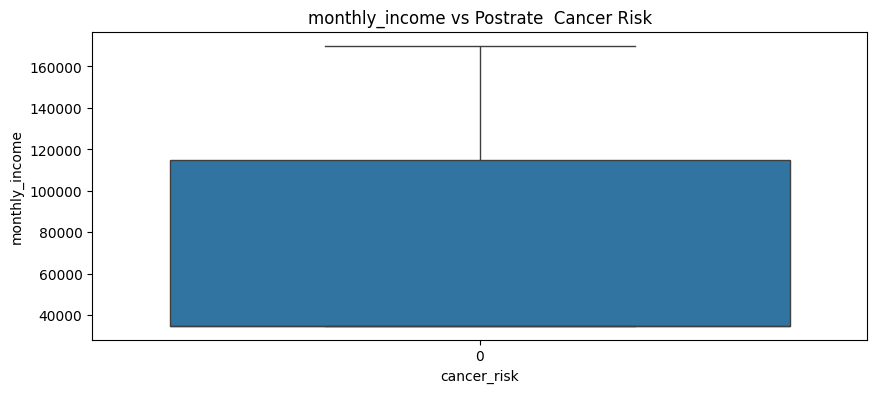

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



hours_of_sleep_per_night:
Correlation = nan, p-value = nan


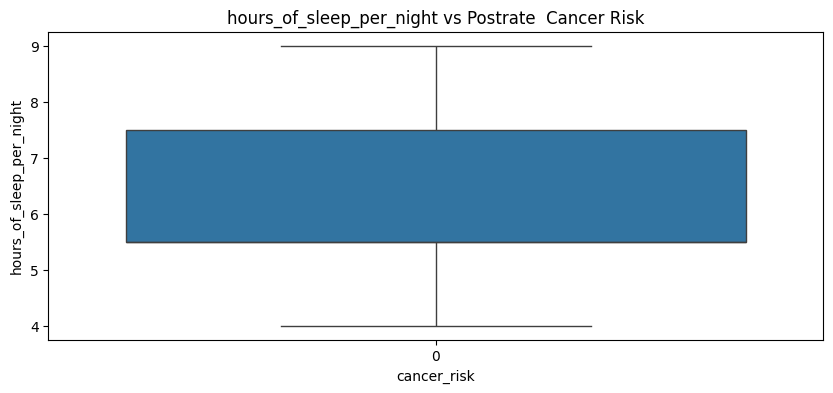

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



age:
Correlation = nan, p-value = nan


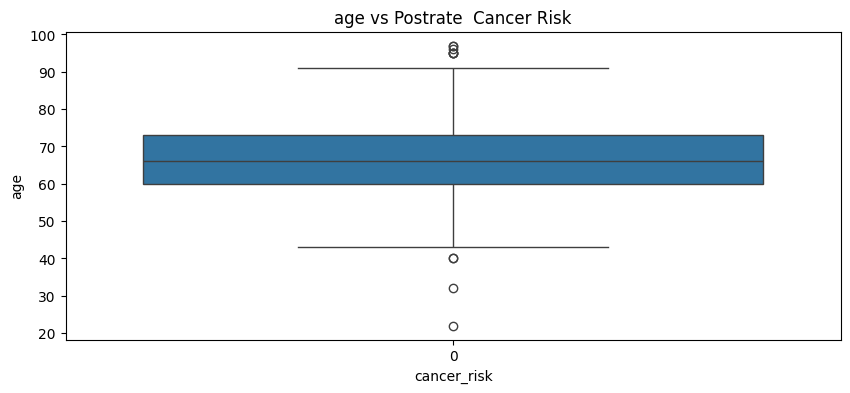


=== ADVANCED ANALYSIS ===

Urinary Symptom Prevalence:
urinary_symptoms
0    988
1     67
Name: count, dtype: int64

Urinary Symptoms vs Postrate  Cancer: Chi2=0.00, p=1.0000

Analysis complete!


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load and prepare data
def load_data(df):
    # Convert all columns to string type for safety
    df = df.applymap(str)
    
    # Create cancer_risk target (1=malignant, 0=benign)
    df['cancer_risk'] = df['categories'].str.lower().str.contains('cancer').astype(int)
    
    # Clean continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    
    return df

# Diagnostic checks
def run_diagnostics(df):
    print("\n=== DATA DIAGNOSTICS ===")
    
    # 1. Check target distribution
    print("\nPostrate Cancer Risk Distribution:")
    print(df['cancer_risk'].value_counts(dropna=False))
    
    # 2. Check missing values
    print("\nMissing Values:")
    print(df.isna().sum())
    
    # 3. Check categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
                'do_you_smoke', 'how_do_you_rate_your_stress_level']
    print("\nCategorical Value Counts:")
    for var in cat_vars:
        if var in df.columns:
            print(f"\n{var}:")
            print(df[var].value_counts(dropna=False))
    
    # 4. Check continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    existing_cont_vars = [var for var in cont_vars if var in df.columns]
    
    if existing_cont_vars:
        print("\nContinuous Variable Summary:")
        print(df[existing_cont_vars].describe())
    else:
        print("\nNo continuous variables found in dataset.")


# Lifestyle correlation analysis
def analyze_lifestyle(df):
    print("\n=== LIFESTYLE FACTOR ANALYSIS ===")
    
    # Categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    
    for var in cat_vars:
        if var in df.columns:
            # Create contingency table
            table = pd.crosstab(df[var], df['cancer_risk'])
            
            # Skip if no variation
            if table.shape[0] < 2 or table.shape[1] < 2:
                print(f"\n{var}: Cannot test - insufficient variation")
                continue
                
            # Chi-square test
            chi2, p, dof, _ = chi2_contingency(table)
            print(f"\n{var}:")
            print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
            print("Contingency Table:")
            print(table)
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.countplot(data=df, x=var, hue='cancer_risk')
            plt.title(f"{var} vs Postrate Cancer Risk")
            plt.show()
    
    # Continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            # Remove missing values
            clean_df = df.dropna(subset=[var, 'cancer_risk'])
            
            # Skip if no variation
            if clean_df[var].nunique() < 2:
                print(f"\n{var}: Cannot test - no variation")
                continue
                
            # Point-biserial correlation
            corr, p = pointbiserialr(clean_df[var], clean_df['cancer_risk'])
            print(f"\n{var}:")
            print(f"Correlation = {corr:.2f}, p-value = {p:.4f}")
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.boxplot(data=clean_df, x='cancer_risk', y=var)
            plt.title(f"{var} vs Postrate  Cancer Risk")
            plt.show()

# Advanced analysis
def advanced_analysis(df):
    print("\n=== ADVANCED ANALYSIS ===")
    
    # 1. Symptom analysis
    if 'symptions' in df.columns:
        df['urinary_symptoms'] = df['symptions'].str.lower().str.contains(
            'dribbling|nocturia|frequent urination', regex=True).astype(int)
        
        # Check symptom prevalence
        print("\nUrinary Symptom Prevalence:")
        print(df['urinary_symptoms'].value_counts())
        
        # Correlation with cancer
        if 'cancer_risk' in df.columns:
            table = pd.crosstab(df['urinary_symptoms'], df['cancer_risk'])
            chi2, p, _, _ = chi2_contingency(table)
            print(f"\nUrinary Symptoms vs Postrate  Cancer: Chi2={chi2:.2f}, p={p:.4f}")
    
    # 2. Predictive modeling
    try:
        features = ['age', 'bmi', 'urinary_symptoms'] 
        features = [f for f in features if f in df.columns]
        
        if features and 'cancer_risk' in df.columns:
            X = df[features].fillna(df[features].median())
            y = df['cancer_risk']
            
            if y.nunique() > 1:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.3, random_state=42)
                
                model = RandomForestClassifier()
                model.fit(X_train, y_train)
                
                print("\nPrediction Model Performance:")
                print(classification_report(y_test, model.predict(X_test)))
                
                print("\nFeature Importances:")
                for name, imp in zip(features, model.feature_importances_):
                    print(f"{name}: {imp:.2f}")
    except Exception as e:
        print(f"\nModeling failed: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')  # Uncomment to load from file
    # Or use your existing DataFrame:
    df = df4.copy()  # Replace df3 with your actual DataFrame name
    
    # Clean and prepare data
    df = load_data(df)
    
    # Run diagnostics
    run_diagnostics(df)
    
    # Core analysis
    analyze_lifestyle(df)
    
    # Advanced analysis
    advanced_analysis(df)
    
    print("\nAnalysis complete!")

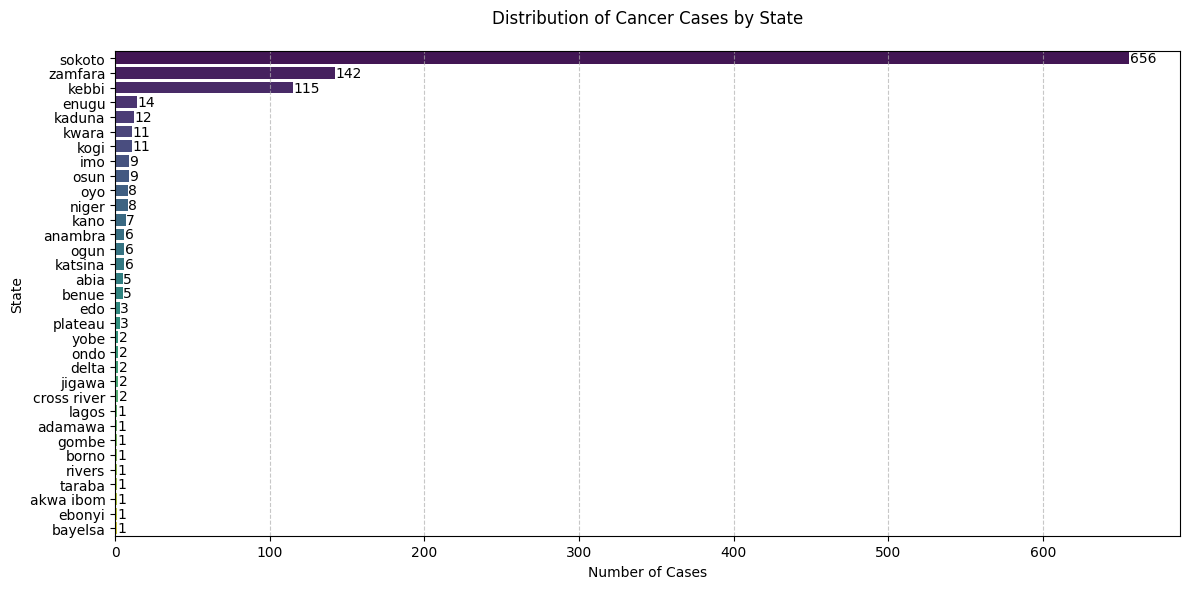

In [18]:
state_counts = df4['state'].value_counts()

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.values,
            y=state_counts.index,
            hue=state_counts.index,  # Added hue
            palette='viridis',
            legend=False)  # Disable legend since we don't need it

plt.title('Distribution of Cancer Cases by State', pad=20)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(state_counts.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

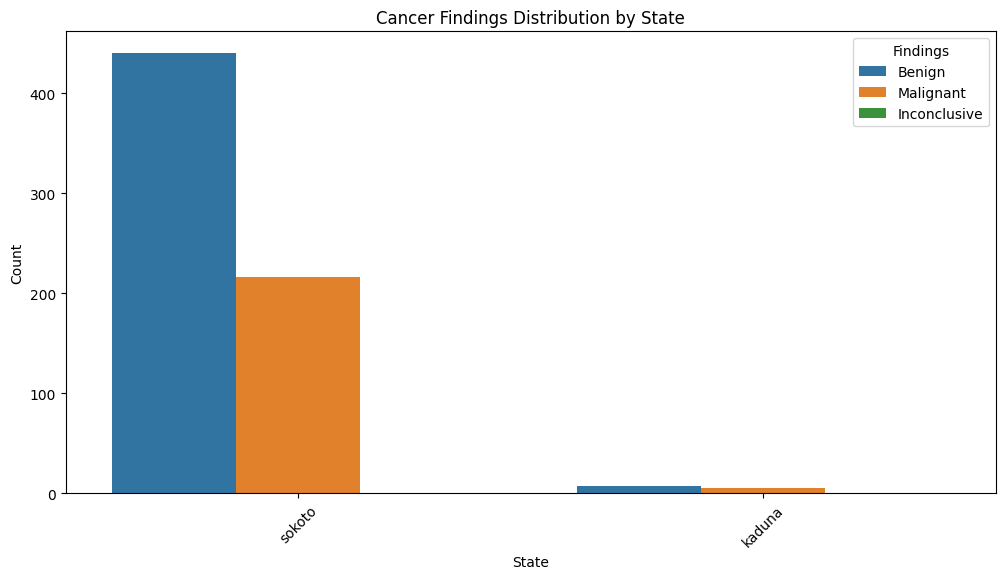

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df4, x='state', hue='categories', order=df4['state'].head(20).value_counts().index)
plt.title('Cancer Findings Distribution by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.xticks(rotation=45)
plt.show()

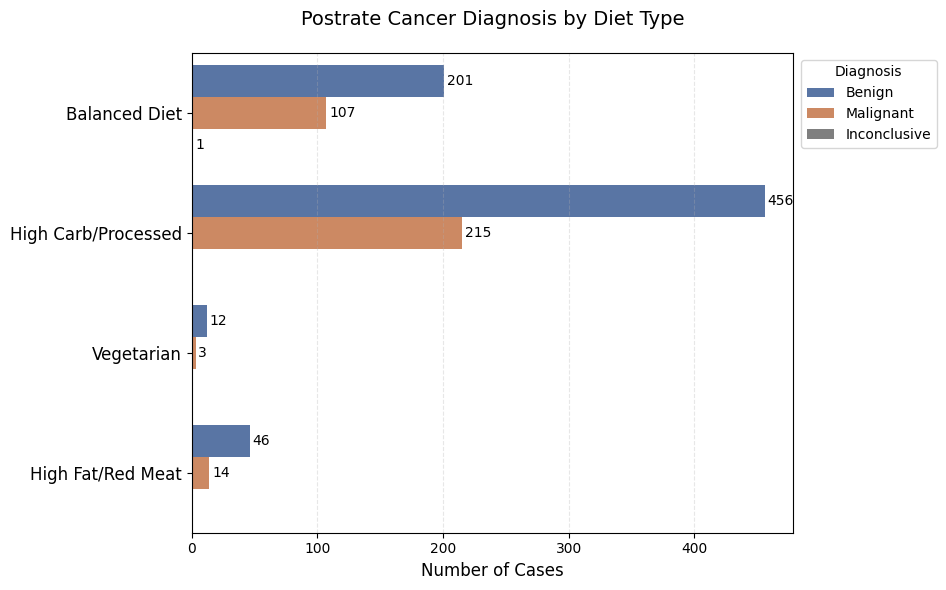

In [20]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Define diet labels
diet_labels = {
    'balance': 'Balanced Diet',
    'high in carbohydrate and processed foods': 'High Carb/Processed',
    'vegetarian': 'Vegetarian',
    'high in fat and red meat': 'High Fat/Red Meat'
}

# Define complete findings palette
findings_palette = {
    'Benign': '#4c72b0',
    'Malignant': '#dd8452',
    'Inconclusive': '#7f7f7f'
}

# Create plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df4,
    y='overall_diet',
    hue='categories',
    order=list(diet_labels.keys()),
    palette=findings_palette
)

# Customize y-axis labels
plt.yticks(
    ticks=range(len(diet_labels)),
    labels=[diet_labels[d] for d in diet_labels.keys()],
    fontsize=12
)

# Add titles and labels
plt.title('Postrate Cancer Diagnosis by Diet Type', pad=20, fontsize=14)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('')
plt.legend(title='Diagnosis', bbox_to_anchor=(1.25, 1))

# Add count labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

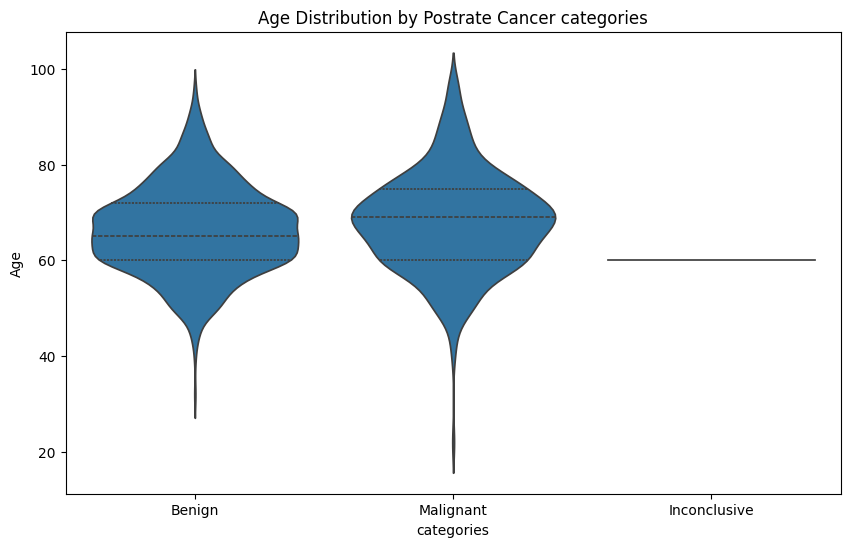

In [22]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df4, x='categories', y='age', inner='quartile')
plt.title('Age Distribution by Postrate Cancer categories')
plt.xlabel('categories')
plt.ylabel('Age')
plt.show()

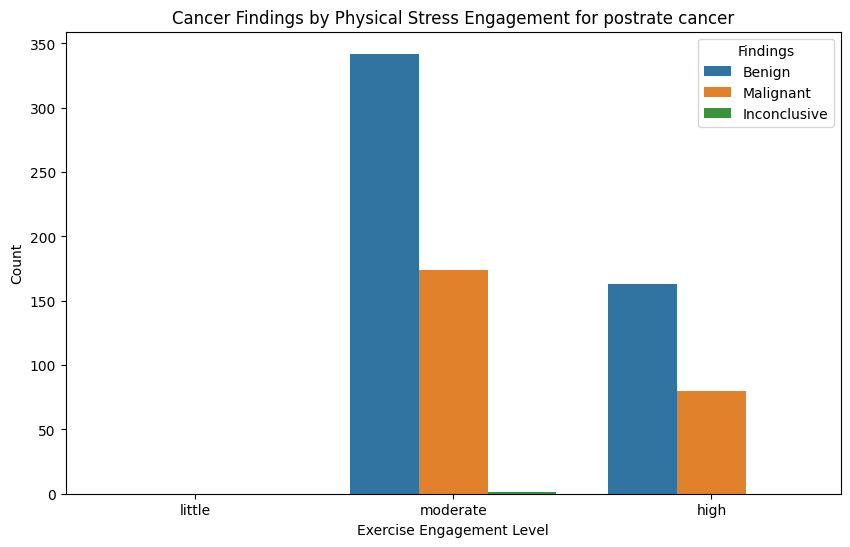

In [26]:

plt.figure(figsize=(10,6))
sns.countplot(data=df4, x='how_do_you_rate_your_stress_level', hue='categories',
             order=['little', 'moderate', 'high'])
plt.title('Cancer Findings by Physical Stress Engagement for postrate cancer')
plt.xlabel('Exercise Engagement Level')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

## Dataset

In [1]:
import pandas as pd
df4 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
df4.head(1)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,...,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,biopsy_cores,findings,categories
0,73,sokoto,married,tertiary,skilled,35000,hausa,self,"dribbling of urine, incomplete voiding, lack o...",153,...,high in carbohydrate and processed foods,2,no,no,moderate,no,7.5,4,prostrate (biopsy)- nodular hyperplasia,Benign


### Observe an imbalnce target class

In [2]:
df4['categories'].value_counts()

categories
Benign       715
Malignant    340
Name: count, dtype: int64

In [3]:
import pandas as pd

# Load your dataset
df4 = pd.read_excel('merged_prostrate_cancer_data.xlsx')

# Drop rows with missing target labels BEFORE encoding
df4 = df4.dropna(subset=['categories'])

# Drop the 'findings' column
df4 = df4.drop(columns=['findings'])

# Separate features (X) and target (y)
X = df4.drop(columns=['categories'])
y_encoded = df4['categories'].map({'Benign': 1, 'Malignant': 0})

# Encode categorical features with one-hot encoding (only ONCE)
X_encoded = pd.get_dummies(X, drop_first=True)

# Preview X and y
print(X_encoded.head(2))
print(y_encoded.head(2))
print(y_encoded.isnull().sum())

   age  monthly_income  height_cm  weight  meals_taken_in_a_day  \
0   73           35000        153      53                     2   
1   58           35000        155      51                     2   

   hours_of_sleep_per_night  biopsy_cores  state_adamawa  state_akwa ibom  \
0                       7.5             4          False            False   
1                       9.0             4          False            False   

   state_anambra  ...  \
0          False  ...   
1          False  ...   

   symptions_weihgt loss, urinary frequency, dysuria, lower back pain, difficulty in walking, weakness  \
0                                              False                                                     
1                                              False                                                     

   overall_diet_high in carbohydrate and processed foods  \
0                                               True       
1                                               Tru

# model preparation


#### RandomForeest Classifier

#### HyperParam Tuning of RFC Model

Applying SMOTE...
Splitting data...
Hyperparameter tuning...
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None, 'bootstrap': True}
Evaluating model...

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       143
           1       0.75      0.86      0.80       143

    accuracy                           0.79       286
   macro avg       0.79      0.79      0.79       286
weighted avg       0.79      0.79      0.79       286

Test ROC AUC: 0.8478654212919947

Confusion Matrix:
[[102  41]
 [ 20 123]]

Top Feature Importances:
biopsy_cores: 0.082
weight: 0.078
height_cm: 0.073
age: 0.072
hours_of_sleep_per_night: 0.056
meals_taken_in_a_day: 0.037
symptions_luts: 0.025
how_do_you_rate_your_stress_level_moderate: 0.025
who_made_you_seek_medical_help_self: 0.022
who_made_you_seek_medical_help_family or friends: 0.022


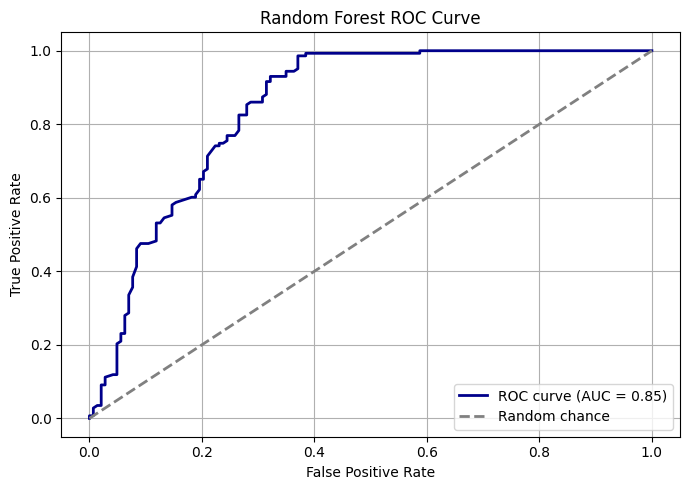

In [4]:
def rf_model_evaluation(X_encoded, y_encoded):
    """
    Full pipeline:
    - SMOTE balancing
    - Train-test split
    - Random Forest hyperparameter tuning (RandomizedSearchCV)
    - Evaluation (classification report, confusion matrix, ROC AUC)
    - Feature importance
    - ROC curve plot

    Parameters:
        X_encoded: pd.DataFrame or np.ndarray, feature matrix
        y_encoded: pd.Series or np.ndarray,  target vector
    """
    from imblearn.over_sampling import SMOTE
    from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
    import matplotlib.pyplot as plt
    import numpy as np

    print("Applying SMOTE...")
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

    print("Splitting data...")
    X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
    )

    print("Hyperparameter tuning...")
    param_dist = {
        'n_estimators': [100, 200, 500, 800],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': ['balanced', 'balanced_subsample', None],
        'bootstrap': [True, False]
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestClassifier(random_state=42)

    rf_search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=50, cv=cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, verbose=0
    )
    rf_search.fit(X_train_res, y_train_res)
    best_rf = rf_search.best_estimator_
    print("Best Parameters:", rf_search.best_params_)

    print("Evaluating model...")
    y_pred_rf = best_rf.predict(X_test_res)
    y_prob_rf = best_rf.predict_proba(X_test_res)[:, 1]

    print("\nClassification Report:")
    print(classification_report(y_test_res, y_pred_rf))
    print("Test ROC AUC:", roc_auc_score(y_test_res, y_prob_rf))

    cm = confusion_matrix(y_test_res, y_pred_rf)
    print("\nConfusion Matrix:")
    print(cm)

    # Feature Importances
    importances = best_rf.feature_importances_
    if hasattr(X_encoded, 'columns'):
        feat_names = X_encoded.columns
    else:
        feat_names = [f"Feature {i}" for i in range(X_encoded.shape[1])]
    print("\nTop Feature Importances:")
    for name, val in sorted(zip(feat_names, importances), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{name}: {val:.3f}")

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test_res, y_prob_rf)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Random Forest ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Return useful objects if user wants to use downstream
    return best_rf, rf_search, cm, (fpr, tpr, roc_auc)

# Example usage:
best_rf, rf_search, cm, roc_data = rf_model_evaluation(X_encoded, y_encoded)


# Supporting Vector Classification Model

Balanced target class (train):
categories
0    572
1    572
Name: count, dtype: int64

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       143
           1       0.73      0.84      0.78       143

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.76       286
weighted avg       0.77      0.77      0.76       286

ROC AUC: 0.8228

Mean Absolute Error (MAE): 0.3432
Mean Squared Error (MSE): 0.1696
Root Mean Squared Error (RMSE): 0.4118
R² Score: 0.3218


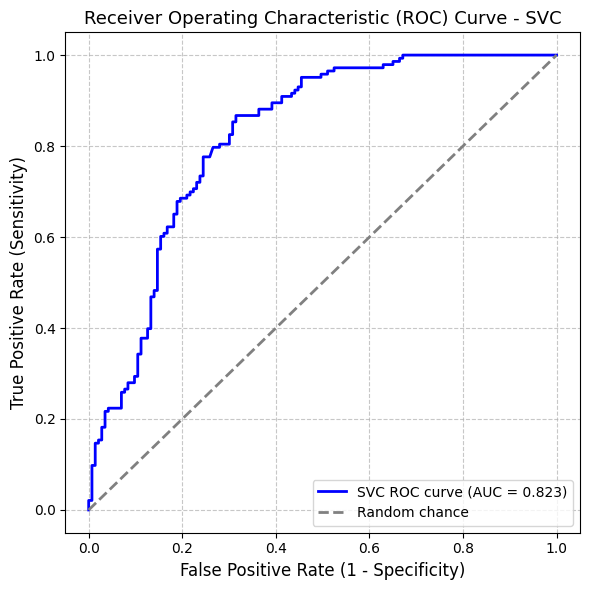

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
import matplotlib.pyplot as plt
import numpy as np

# ====== 1️⃣ Resample with SMOTE ======
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

# ====== 2️⃣ Split dataset ======
X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print('Balanced target class (train):')
print(y_train_sm.value_counts())

# ====== 3️⃣ Scale features ======
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test_sm)

# ====== 4️⃣ Train SVC Model ======
svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train_sm)

# ====== 5️⃣ Predictions & Probabilities ======
y_pred_svc = svc_model.predict(X_test_scaled)
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

# ====== 6️⃣ Classification & ROC-AUC ======
print("\nClassification Report:\n", classification_report(y_test_sm, y_pred_svc))
roc_auc = roc_auc_score(y_test_sm, y_prob_svc)
print(f"ROC AUC: {roc_auc:.4f}")

# ====== 7️⃣ Regression-style Metrics (for probabilities) ======
mae = mean_absolute_error(y_test_sm, y_prob_svc)
mse = mean_squared_error(y_test_sm, y_prob_svc)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_sm, y_prob_svc)

print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# ====== 8️⃣ Plot ROC Curve ======
fpr, tpr, thresholds = roc_curve(y_test_sm, y_prob_svc)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'SVC ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random chance')
plt.title('Receiver Operating Characteristic (ROC) Curve - SVC', fontsize=13)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Balanced target class (train):
categories
0    572
1    572
Name: count, dtype: int64

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       143
           1       0.73      0.84      0.78       143

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.76       286
weighted avg       0.77      0.77      0.76       286

ROC AUC: 0.8228

Mean Absolute Error (MAE): 0.3432
Mean Squared Error (MSE): 0.1696
Root Mean Squared Error (RMSE): 0.4118
R² Score: 0.3218


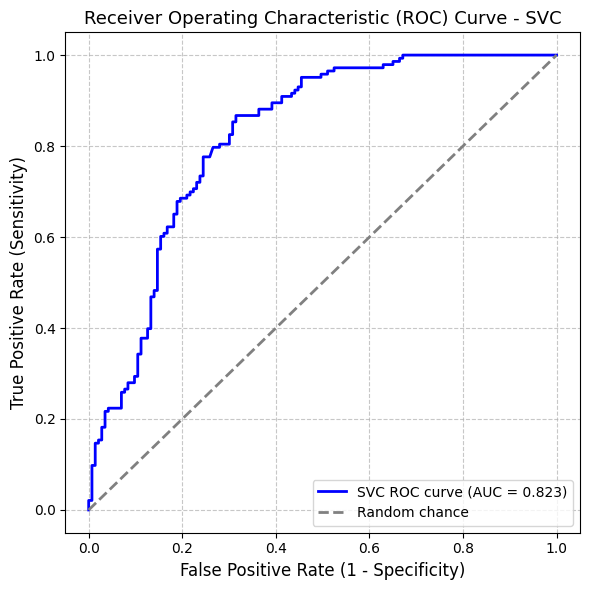

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
import matplotlib.pyplot as plt
import numpy as np


def train_evaluate_svc(X, y, test_size=0.2, random_state=42):
    """
    Train an SVC model with SMOTE balancing, scaling, and evaluation metrics.

    Parameters:
        X (DataFrame or array): Feature set
        y (Series or array): Target labels
        test_size (float): Fraction of data for testing
        random_state (int): Seed for reproducibility
    """

    # ====== 1️⃣ Resample with SMOTE ======
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X, y)

    # ====== 2️⃣ Split dataset ======
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=test_size, random_state=random_state, stratify=y_res
    )
    print('Balanced target class (train):')
    print(y_train.value_counts())

    # ====== 3️⃣ Scale features ======
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ====== 4️⃣ Train SVC Model ======
    svc_model = SVC(probability=True, random_state=random_state)
    svc_model.fit(X_train_scaled, y_train)

    # ====== 5️⃣ Predictions & Probabilities ======
    y_pred = svc_model.predict(X_test_scaled)
    y_prob = svc_model.predict_proba(X_test_scaled)[:, 1]

    # ====== 6️⃣ Classification & ROC-AUC ======
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC AUC: {roc_auc:.4f}")

    # ====== 7️⃣ Regression-style Metrics ======
    mae = mean_absolute_error(y_test, y_prob)
    mse = mean_squared_error(y_test, y_prob)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_prob)

    print(f"\nMean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # ====== 8️⃣ Plot ROC Curve ======
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'SVC ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random chance')
    plt.title('Receiver Operating Characteristic (ROC) Curve - SVC', fontsize=13)
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return svc_model, roc_auc, mae, mse, rmse, r2
svc_model, roc_auc, mae, mse, rmse, r2 = train_evaluate_svc(X_encoded, y_encoded)


### 📊 Gradient Boosting Regressor Evaluation Metrics

This is a balance target class:  categories
0    572
1    572
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.73      0.68      0.71       143
           1       0.70      0.76      0.73       143

    accuracy                           0.72       286
   macro avg       0.72      0.72      0.72       286
weighted avg       0.72      0.72      0.72       286

ROC AUC: 0.7957357327986698
Mean Absolute Error (MAE): 0.3795
Mean Squared Error (MSE): 0.1793
Root Mean Squared Error (RMSE): 0.4234
R² Score: 0.2828


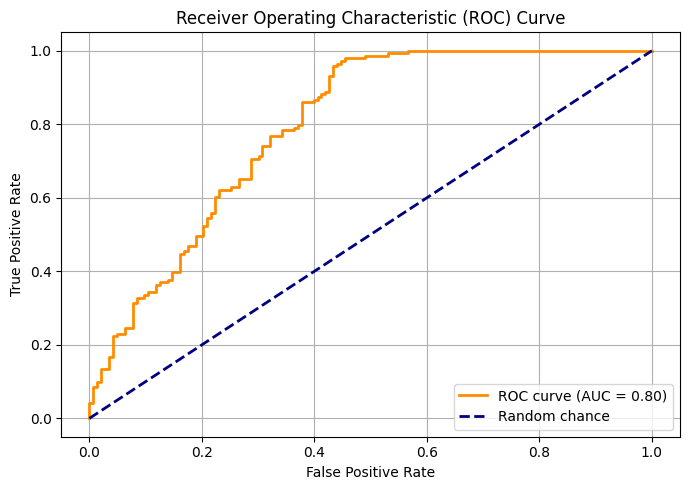

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: SMOTE oversampling
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_encoded, y_encoded)

# Step 2: Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print('This is a balance target class: ',y_train.value_counts())
# Step 3: Train Gradient Boosting on resampled data
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbc_model.fit(X_train, y_train)

# Step 4: Evaluate
y_pred = gbc_model.predict(X_test)
y_prob = gbc_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# y_prob is already defined, from your GradientBoostingClassifier
# y_prob = gbc_model.predict_proba(X_test)[:, 1]

mae = mean_absolute_error(y_test, y_prob)
mse = mean_squared_error(y_test, y_prob)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_prob)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


# Calculate ROC curve points and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()



Balanced training target class counts:
categories
0    572
1    572
Name: count, dtype: int64

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.71       143
           1       0.70      0.76      0.73       143

    accuracy                           0.72       286
   macro avg       0.72      0.72      0.72       286
weighted avg       0.72      0.72      0.72       286

ROC AUC: 0.7957

Mean Absolute Error (MAE): 0.3795
Mean Squared Error (MSE): 0.1793
Root Mean Squared Error (RMSE): 0.4234
R² Score: 0.2828


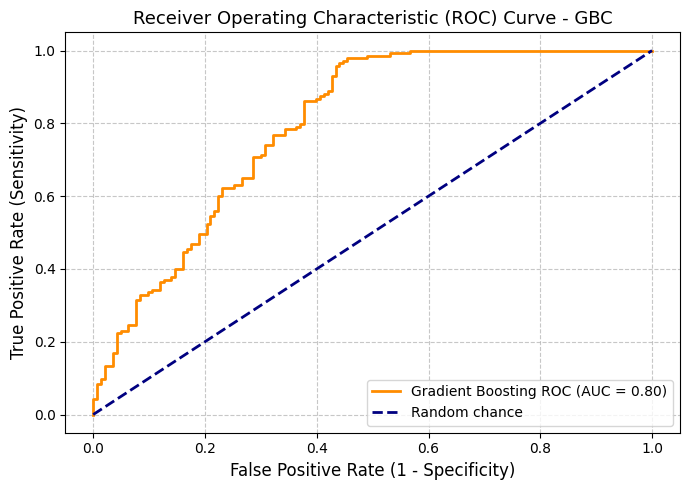

In [40]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)
import matplotlib.pyplot as plt
import numpy as np


def train_evaluate_gbc(X, y, test_size=0.2, random_state=42):
    """
    Train a Gradient Boosting Classifier with SMOTE balancing, 
    evaluate its performance, and plot the ROC curve.

    Parameters:
        X (DataFrame or array): Features
        y (Series or array): Target labels
        test_size (float): Proportion for test split
        random_state (int): Random seed

    Returns:
        model: Trained Gradient Boosting model
        metrics (dict): Dictionary of key evaluation metrics
    """

    # ===== 1️⃣ SMOTE Oversampling =====
    sm = SMOTE(random_state=random_state)
    X_res, y_res = sm.fit_resample(X, y)

    # ===== 2️⃣ Split Data =====
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=test_size, random_state=random_state, stratify=y_res
    )
    print("\nBalanced training target class counts:")
    print(y_train.value_counts())

    # ===== 3️⃣ Train Gradient Boosting Model =====
    gbc_model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, random_state=random_state
    )
    gbc_model.fit(X_train, y_train)

    # ===== 4️⃣ Predictions =====
    y_pred = gbc_model.predict(X_test)
    y_prob = gbc_model.predict_proba(X_test)[:, 1]

    # ===== 5️⃣ Classification Metrics =====
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC AUC: {roc_auc:.4f}")

    # ===== 6️⃣ Regression-style Metrics =====
    mae = mean_absolute_error(y_test, y_prob)
    mse = mean_squared_error(y_test, y_prob)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_prob)

    print(f"\nMean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    # ===== 7️⃣ Plot ROC Curve =====
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Gradient Boosting ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2,
             linestyle='--', label='Random chance')
    plt.title('Receiver Operating Characteristic (ROC) Curve - GBC', fontsize=13)
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ===== 8️⃣ Return Model and Metrics =====
    metrics = {
        "roc_auc": roc_auc,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2
    }

    return gbc_model, metrics
gbc_model, gbc_metrics = train_evaluate_gbc(X_encoded, y_encoded)


### Ensemble Model

              precision    recall  f1-score   support

           0       0.83      0.76      0.80       143
           1       0.78      0.85      0.81       143

    accuracy                           0.80       286
   macro avg       0.81      0.80      0.80       286
weighted avg       0.81      0.80      0.80       286

ROC AUC: 0.8615580223971833
Confusion Matrix:
 [[109  34]
 [ 22 121]]


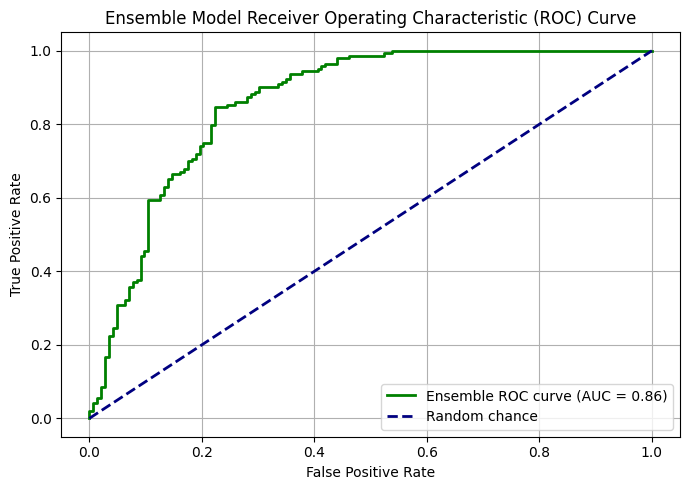

In [28]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
# SVC (with scaling)
svc_model = SVC(probability=True, random_state=42)
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Gradient Boosting
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit each base estimator separately if needed (optional with VotingClassifier)

# Build the ensemble voting classifier
ensemble = VotingClassifier(
    estimators=[
        ('svc', svc_model),
        ('rf', best_rf),
        ('gbc', gbc_model)
    ],
    voting='soft'  # Use soft voting to average predicted probabilities
)

# Use SMOTE-resampled, unscaled data for RandomForest/GradientBoosting;
# Use scaled data for SVC
ensemble.fit(X_train_scaled, y_train_sm)

# Predict on test data (be sure to scale X_test for SVC as before)
y_pred_ensemble = ensemble.predict(X_test_scaled)
y_prob_ensemble = ensemble.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test_sm, y_pred_ensemble))
print("ROC AUC:", roc_auc_score(y_test_sm, y_prob_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test_sm, y_pred_ensemble))

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_sm, y_prob_ensemble)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Ensemble ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Model Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(ensemble, X_train_scaled, y_train_sm, cv=5, scoring='roc_auc')
print("Mean CV ROC AUC:", scores.mean())

ensemble = VotingClassifier(
    estimators=[('svc', svc_model), ('rf', best_rf), ('gbc', gbc_model)],
    voting='soft',
    weights=[1, 2, 2]  # give more influence to RF and GBC
)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test_sm, y_pred_ensemble))



Mean CV ROC AUC: 0.8260357032933211
[[109  34]
 [ 22 121]]


In [33]:
import pandas as pd

sample_indices = range(5)  # First five positions

# Use .iloc for positional indexing!
comparison_df = pd.DataFrame({
    'Actual': y_test_sm.iloc[sample_indices],
    'Predicted': y_pred_ensemble[sample_indices]
})

print(comparison_df)


      Actual  Predicted
1318       0          0
1358       0          0
709        1          1
1289       0          0
146        1          1


In [34]:
import numpy as np

rnd_idx = np.random.choice(len(y_test_sm), 5, replace=False)
comparison_df = pd.DataFrame({
    'Actual': np.array(y_test_sm)[rnd_idx],
    'Predicted': np.array(y_pred_ensemble)[rnd_idx]
})
print(comparison_df)


   Actual  Predicted
0       1          1
1       0          0
2       0          1
3       0          0
4       1          1



SVC Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       143
           1       0.73      0.84      0.78       143

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.76       286
weighted avg       0.77      0.77      0.76       286

Random Forest Report:
               precision    recall  f1-score   support

           0       0.84      0.71      0.77       143
           1       0.75      0.86      0.80       143

    accuracy                           0.79       286
   macro avg       0.79      0.79      0.79       286
weighted avg       0.79      0.79      0.79       286

Gradient Boost Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.71       143
           1       0.70      0.76      0.73       143

    accuracy                           0.72       286
   macro avg       0.72      0.72      0.72       286
weighted avg 

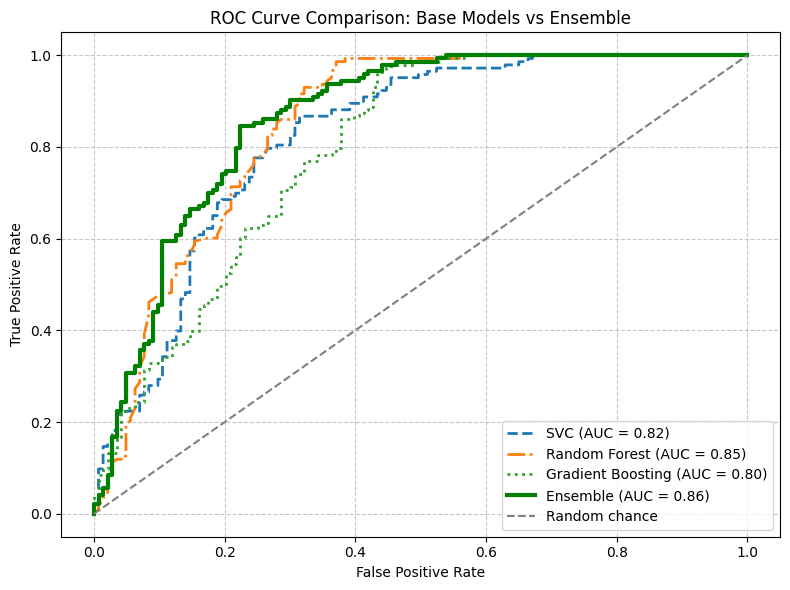


First 5 Actual vs Predicted:
    Actual  Predicted
0       0          0
1       0          0
2       1          1
3       0          0
4       1          1


In [36]:
# --- Imports ---
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# --- Fit all models ---
svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train_sm)

# Use your hyperparameter-tuned RandomForest (from RandomizedSearchCV)
best_rf.fit(X_train_scaled, y_train_sm)

gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbc_model.fit(X_train_scaled, y_train_sm)

# --- Ensemble (VotingClassifier) ---
ensemble = VotingClassifier(
    estimators=[
        ('svc', svc_model),
        ('rf', best_rf),
        ('gbc', gbc_model)
    ],
    voting='soft'
)
ensemble.fit(X_train_scaled, y_train_sm)

# --- Predict probabilities ---
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = best_rf.predict_proba(X_test_scaled)[:, 1]
y_prob_gbc = gbc_model.predict_proba(X_test_scaled)[:, 1]
y_prob_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

# --- Classification Reports ---
print("\nSVC Report:\n", classification_report(y_test_sm, svc_model.predict(X_test_scaled)))
print("Random Forest Report:\n", classification_report(y_test_sm, best_rf.predict(X_test_scaled)))
print("Gradient Boost Report:\n", classification_report(y_test_sm, gbc_model.predict(X_test_scaled)))
print("Ensemble Report:\n", classification_report(y_test_sm, ensemble.predict(X_test_scaled)))

# --- ROC AUC Scores ---
print(f"SVC ROC AUC: {roc_auc_score(y_test_sm, y_prob_svc):.4f}")
print(f"RF ROC AUC: {roc_auc_score(y_test_sm, y_prob_rf):.4f}")
print(f"GBC ROC AUC: {roc_auc_score(y_test_sm, y_prob_gbc):.4f}")
print(f"Ensemble ROC AUC: {roc_auc_score(y_test_sm, y_prob_ens):.4f}")

# --- Confusion Matrices ---
print("Ensemble Confusion Matrix:\n", confusion_matrix(y_test_sm, ensemble.predict(X_test_scaled)))

# --- ROC Curve Calculation ---
fpr_svc, tpr_svc, _ = roc_curve(y_test_sm, y_prob_svc)
fpr_rf, tpr_rf, _   = roc_curve(y_test_sm, y_prob_rf)
fpr_gbc, tpr_gbc, _ = roc_curve(y_test_sm, y_prob_gbc)
fpr_ens, tpr_ens, _ = roc_curve(y_test_sm, y_prob_ens)

auc_svc  = auc(fpr_svc, tpr_svc)
auc_rf   = auc(fpr_rf, tpr_rf)
auc_gbc  = auc(fpr_gbc, tpr_gbc)
auc_ens  = auc(fpr_ens, tpr_ens)

# --- Plot ROC Curves ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_svc, tpr_svc, lw=2, label=f'SVC (AUC = {auc_svc:.2f})', linestyle='--')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})', linestyle='-.')
plt.plot(fpr_gbc, tpr_gbc, lw=2, label=f'Gradient Boosting (AUC = {auc_gbc:.2f})', linestyle=':')
plt.plot(fpr_ens, tpr_ens, lw=3, color='green', label=f'Ensemble (AUC = {auc_ens:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Base Models vs Ensemble')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Actual vs. Predicted Table (first 5 samples) ---
import pandas as pd
comparison_df = pd.DataFrame({
    'Actual': np.array(y_test_sm)[:5],
    'Predicted': ensemble.predict(X_test_scaled)[:5]
})
print("\nFirst 5 Actual vs Predicted:\n", comparison_df)



SVC Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75       143
           1       0.73      0.84      0.78       143

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.76       286
weighted avg       0.77      0.77      0.76       286

Random Forest Report:
               precision    recall  f1-score   support

           0       0.84      0.71      0.77       143
           1       0.75      0.86      0.80       143

    accuracy                           0.79       286
   macro avg       0.79      0.79      0.79       286
weighted avg       0.79      0.79      0.79       286

Gradient Boost Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.71       143
           1       0.70      0.76      0.73       143

    accuracy                           0.72       286
   macro avg       0.72      0.72      0.72       286
weighted avg 

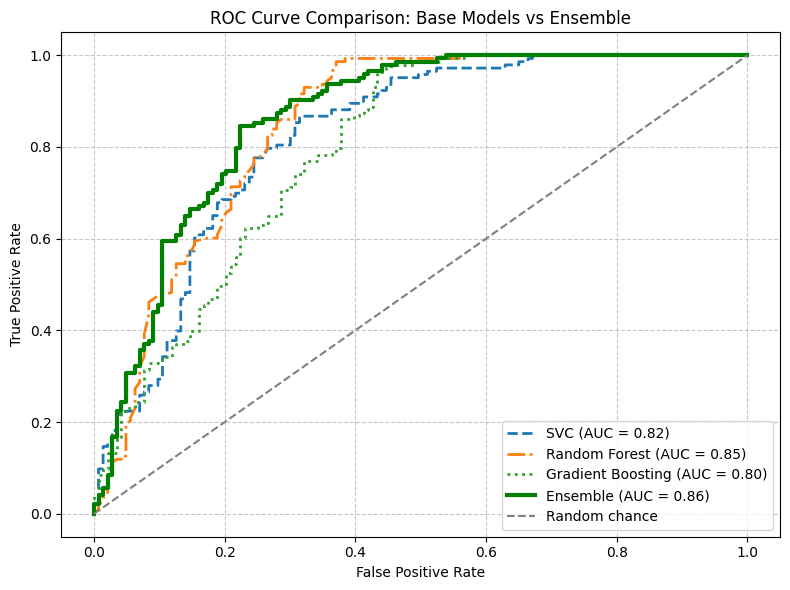


First 5 Actual vs Predicted:
    Actual  Predicted
0       0          0
1       0          0
2       1          1
3       0          0
4       1          1


In [42]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def evaluate_voting_ensemble(X_train_scaled, X_test_scaled, y_train, y_test, best_rf=None):
    """
    Train and compare SVC, RandomForest, and GradientBoosting models,
    then combine them into a soft-voting ensemble. Evaluate and visualize performance.

    Parameters:
        X_train_scaled (array): Scaled training features
        X_test_scaled (array): Scaled test features
        y_train (array): Training labels
        y_test (array): Test labels
        best_rf (model, optional): Pre-tuned RandomForest model (from RandomizedSearchCV).
                                   If None, a default RF will be used.

    Returns:
        results (dict): Dictionary containing trained models and metrics
    """

    # --- 1️⃣ Initialize models ---
    svc_model = SVC(probability=True, random_state=42)
    rf_model = best_rf if best_rf is not None else RandomForestClassifier(n_estimators=100, random_state=42)
    gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

    # --- 2️⃣ Fit base models ---
    svc_model.fit(X_train_scaled, y_train)
    rf_model.fit(X_train_scaled, y_train)
    gbc_model.fit(X_train_scaled, y_train)

    # --- 3️⃣ Ensemble model ---
    ensemble = VotingClassifier(
        estimators=[('svc', svc_model), ('rf', rf_model), ('gbc', gbc_model)],
        voting='soft'
    )
    ensemble.fit(X_train_scaled, y_train)

    # --- 4️⃣ Predict probabilities ---
    y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]
    y_prob_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]
    y_prob_gbc = gbc_model.predict_proba(X_test_scaled)[:, 1]
    y_prob_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

    # --- 5️⃣ Classification Reports ---
    print("\nSVC Report:\n", classification_report(y_test, svc_model.predict(X_test_scaled)))
    print("Random Forest Report:\n", classification_report(y_test, rf_model.predict(X_test_scaled)))
    print("Gradient Boost Report:\n", classification_report(y_test, gbc_model.predict(X_test_scaled)))
    print("Ensemble Report:\n", classification_report(y_test, ensemble.predict(X_test_scaled)))

    # --- 6️⃣ ROC AUC Scores ---
    auc_svc = roc_auc_score(y_test, y_prob_svc)
    auc_rf = roc_auc_score(y_test, y_prob_rf)
    auc_gbc = roc_auc_score(y_test, y_prob_gbc)
    auc_ens = roc_auc_score(y_test, y_prob_ens)

    print(f"SVC ROC AUC: {auc_svc:.4f}")
    print(f"RF ROC AUC: {auc_rf:.4f}")
    print(f"GBC ROC AUC: {auc_gbc:.4f}")
    print(f"Ensemble ROC AUC: {auc_ens:.4f}")

    # --- 7️⃣ Confusion Matrix ---
    cm = confusion_matrix(y_test, ensemble.predict(X_test_scaled))
    print("\nEnsemble Confusion Matrix:\n", cm)

    # --- 8️⃣ ROC Curve Plot ---
    fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
    fpr_gbc, tpr_gbc, _ = roc_curve(y_test, y_prob_gbc)
    fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ens)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_svc, tpr_svc, lw=2, label=f'SVC (AUC = {auc_svc:.2f})', linestyle='--')
    plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})', linestyle='-.')
    plt.plot(fpr_gbc, tpr_gbc, lw=2, label=f'Gradient Boosting (AUC = {auc_gbc:.2f})', linestyle=':')
    plt.plot(fpr_ens, tpr_ens, lw=3, color='green', label=f'Ensemble (AUC = {auc_ens:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison: Base Models vs Ensemble')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- 9️⃣ Actual vs Predicted (Preview) ---
    comparison_df = pd.DataFrame({
        'Actual': np.array(y_test)[:5],
        'Predicted': ensemble.predict(X_test_scaled)[:5]
    })
    print("\nFirst 5 Actual vs Predicted:\n", comparison_df)

    # --- 🔟 Return results ---
    results = {
        "svc_model": svc_model,
        "rf_model": rf_model,
        "gbc_model": gbc_model,
        "ensemble": ensemble,
        "auc_scores": {
            "svc": auc_svc,
            "rf": auc_rf,
            "gbc": auc_gbc,
            "ensemble": auc_ens
        },
        "confusion_matrix": cm
    }

    return results

results = evaluate_voting_ensemble(
    X_train_scaled, X_test_scaled, y_train_sm, y_test_sm, best_rf=rf_search.best_estimator_
)

